In [2]:
import numpy as np
import pandas as pd 
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.colors import hsv_to_rgb
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
%matplotlib inline
import seaborn as sns
sns.set_style("whitegrid")
import os

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [4]:
path="/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/01.eQTL/v1.min40_split"
dftis = pd.read_csv(f'{path}/../tissue40.list', sep='\t')
tislist = list(dftis['Tissue'])
tisorder = pd.read_csv("/storage/public/home/2020060185/jupyter/sheepGTEx/00.metadata/tissue.order",sep="\t")
palette = tisorder.set_index('Tissue (QTL)')['Color'].to_dict()

In [9]:
color_dict = {
    'eQTL': '#FF5733',
    'eeQTL': '#FFC300',
    'isoQTL': '#FF8D1A',
    'enQTL': '#CD853F',
    'sQTL': '#55A868',
    'stQTL': '#3A5FCD',
    '3aQTL': '#984EA3',
    'background': '#555555'
}

# Fig. 2a

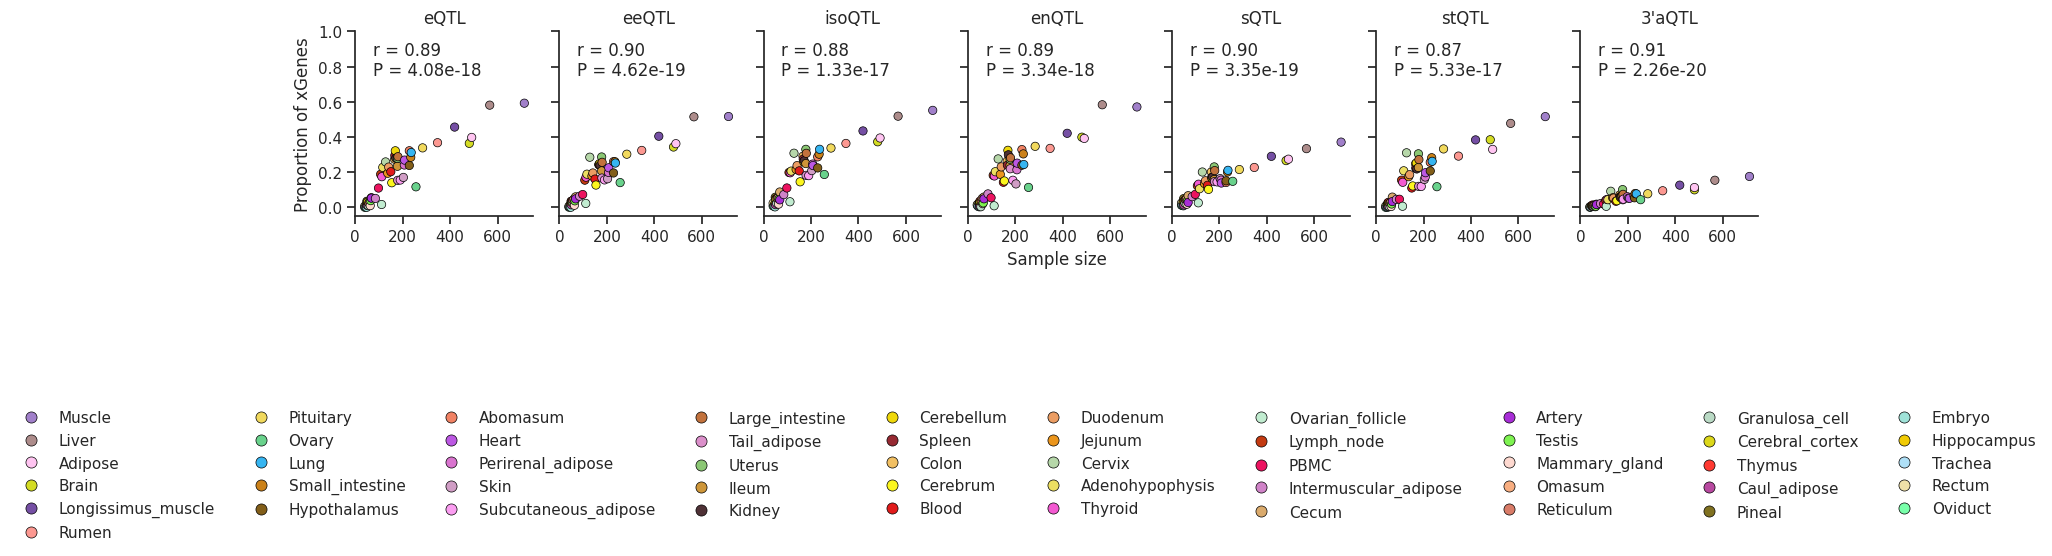

In [21]:
path="/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/combine_results"

sns.set_theme(style="ticks")
fig, axes = plt.subplots(nrows=1, ncols=7, sharex=True, sharey=True, figsize=(15, 4.5))


first_df = pd.read_csv(f'{path}/sheep_eqtl_summary.txt', sep='\t')
tissue_size_dict = first_df[['Tissue', 'Sample size']].drop_duplicates().set_index('Tissue')['Sample size']
sorted_tissues = tissue_size_dict.sort_values(ascending=False).index.tolist()

prefix = ['e', 'ee', 'iso', 'en', 's', 'st', '3a']
for i, p in enumerate(prefix):
    plt.subplot(1, 7, i+1)
    df = pd.read_csv(f'{path}/sheep_{p}qtl_summary.txt', sep='\t')
        
    if p=='3a':
        ax= sns.scatterplot(data=df, x='Sample size', y=f"Proportion of {p}'Genes",
                        hue="Tissue", palette=palette, alpha=1, linewidth=0.5, edgecolor="black", legend=False)
        plt.title("3'aQTL")
        r, P = stats.pearsonr(df['Sample size'], df[f"Proportion of 3a'Genes"])
        ax.text(0.1, 0.95, f'r = {r:.2f}\nP = {P:.2e}', ha='left', va='top', transform=ax.transAxes)
    else:
        ax= sns.scatterplot(data=df, x='Sample size', y=f"Proportion of {p}Genes",
                        hue="Tissue", palette=palette, alpha=1, linewidth=0.5, edgecolor="black", legend=False)
        plt.title(f"{p}QTL")
        r, P = stats.pearsonr(df['Sample size'], df[f'Proportion of {p}Genes'])
        ax.text(0.1, 0.95, f'r = {r:.2f}\nP = {P:.2e}', ha='left', va='top', transform=ax.transAxes)
        
    plt.ylabel('')
    plt.xlabel('')
    plt.xlim(0,750)
    plt.ylim(-0.05,1)
    
    if i==0:
        plt.ylabel('Proportion of xGenes')
    if i==3:
        plt.xlabel('Sample size')

plt.xticks(np.arange(0,800, 200))


handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=palette[tissue], 
                    markersize=8, label=tissue, markeredgecolor='black', markeredgewidth=0.5) 
         for tissue in sorted_tissues]


fig.legend(handles=handles, labels=sorted_tissues, 
           loc='lower center', bbox_to_anchor=(0.5, -0.25), 
           ncol=10, frameon=False)


plt.tight_layout()
plt.subplots_adjust(bottom=0.5) 

sns.despine()
plt.savefig('pdf/summay_molQTL_numbers.pdf', dpi='figure', format='pdf', bbox_inches='tight')

# Fig. 2b-e

In [11]:
path="/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/qtl_coloc"
#df_egene = pd.read_csv(f'{path}/isegene.txt', sep='\t')
#df_egene['nan_num'] = df_egene.iloc[:, 2:9].isna().sum(axis=1)
#df_egene['egene_num'] = df_egene.iloc[:, 2:9].sum(axis=1)
#df_egene['num'] = df_egene['egene_num']
#df_egene.loc[df_egene['num']>=3, 'num'] = 3
#df_egene.to_csv(f"{path}/egene_sharing.txt", sep='\t', index=False)
df_egene = pd.read_csv(f"{path}/egene_sharing.txt", sep="\t")
df_egene_count = df_egene.loc[df_egene['nan_num']<7, ['tissue', 'phenotype_id', 'nan_num', 'egene_num', 'num']]
df_egene_count = pd.merge(df_egene_count, dftis, left_on='tissue', right_on="Tissue")
df_egene_count

,tissue,phenotype_id,nan_num,egene_num,num,Tissue,Sample size,PEER
0,Abomasum,LOC114113923,4,2,2,Abomasum,228,30
1,Abomasum,LOC114112459,5,0,0,Abomasum,228,30
2,Abomasum,PDCD1,4,0,0,Abomasum,228,30
3,Abomasum,GAL3ST2,5,2,2,Abomasum,228,30
4,Abomasum,D2HGDH,1,5,3,Abomasum,228,30
...,...,...,...,...,...,...,...,...
999818,Uterus,LOC101114164,6,0,0,Uterus,178,30
999819,Uterus,LOC114116502,6,0,0,Uterus,178,30
999820,Uterus,DRGX,6,1,1,Uterus,178,30
999821,Uterus,LOC114115051,6,1,1,Uterus,178,30


## cis-heritability

In [40]:
path="/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/01.eQTL/v1.min40_split"
df_h2 = pd.read_csv(f'{path}/omiga_h2.single.txt', sep='\t')
df_h2 = df_h2.dropna(subset=['h2_g1'])
df_h2['h2_g1'] = df_h2['h2_g1'].astype(float)
df_h2 = df_h2[df_h2['model']=='Ac'] # cis-heritability
df_h2 = pd.merge(df_h2, df_egene_count, left_on=["Tissue", "pheno_id"], right_on=["Tissue", "phenotype_id"])
df_h2

,Tissue,Sample_size,pheno_id,chrom,glo_snps,trans_snps,cis_snps,algo,model,vg1,...,h2_g1,h2se_g1,converged,tissue,phenotype_id,nan_num,egene_num,num,Sample size,PEER
0,Muscle,713,LOC114113923,chr1,3316907,0,4019,em_aireml,Ac,2.439230e-01,...,0.355532,0.005478,True,Muscle,LOC114113923,4,2,2,713,60
1,Muscle,713,LOC114112459,chr1,3316907,0,4019,em_aireml,Ac,5.875010e-02,...,0.091126,0.001842,True,Muscle,LOC114112459,5,0,0,713,60
2,Muscle,713,FAM240C,chr1,3316907,0,4076,em_aireml,Ac,2.048970e-02,...,0.038188,0.000762,True,Muscle,FAM240C,6,0,0,713,60
3,Muscle,713,NEU4,chr1,3316907,0,4173,em_aireml,Ac,1.574600e-02,...,0.046005,0.000849,True,Muscle,NEU4,5,2,2,713,60
4,Muscle,713,D2HGDH,chr1,3316907,0,4173,em_aireml,Ac,3.759840e-02,...,0.440640,0.003867,True,Muscle,D2HGDH,1,5,3,713,60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
968863,Oviduct,40,UBE2E2,chr26,2811609,0,2864,em_aireml,Ac,2.443640e-02,...,0.141179,0.071539,True,Oviduct,UBE2E2,1,0,0,40,15
968864,Oviduct,40,LOC121818045,chr26,2811609,0,2864,em_aireml,Ac,4.354320e-01,...,0.537230,0.204245,True,Oviduct,LOC121818045,4,0,0,40,15
968865,Oviduct,40,LOC121818036,chr26,2811609,0,2790,em_aireml,Ac,1.428310e-01,...,0.224255,0.118954,True,Oviduct,LOC121818036,5,0,0,40,15
968866,Oviduct,40,ZNF385D,chr26,2811609,0,1313,em_aireml,Ac,3.795680e-03,...,0.010842,0.018129,True,Oviduct,ZNF385D,3,0,0,40,15


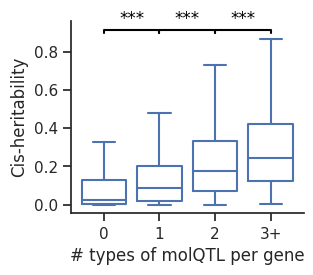

In [7]:
df_plot = df_h2
ylabel = 'h2_g1'

sns.set_theme(style="ticks")
plt.figure(figsize=(3, 2.5))

ax = sns.boxplot(data=df_plot, y=ylabel, x='num', fill=False, showfliers=False)
plt.xlabel('# types of molQTL per gene')
plt.ylabel('cis-heritability')
plt.xticks([0,1,2,3], [0,1,2,'3+'])

#y_max = max(df_plot[ylabel]) * 1.1
y_max = 0.9
pairs=[(0,1), (1, 2), (2, 3)]
for pair in pairs:
    t_stat, p_value = stats.mannwhitneyu(df_plot.loc[df_plot['num']==pair[0],ylabel],
                                         df_plot.loc[df_plot['num']==pair[1],ylabel], alternative='two-sided')
    if p_value < 0.001:
        significance = '***'
    elif p_value < 0.01:
        significance = '**'
    elif p_value < 0.05:
        significance = '*'
    else:
        significance = 'ns' 
    ax.plot([pair[0], pair[0], pair[1], pair[1]], [y_max, y_max * 1.02, y_max * 1.02, y_max], lw=1.5, c='black')
    ax.text((pair[0] + pair[1]) * 0.5, y_max * 1.03, significance, ha='center', va='bottom', color='black')
plt.savefig('pdf/Cis-heritability_molQTL.pdf', dpi='figure', format='pdf', bbox_inches='tight')
sns.despine()

## TAU

In [47]:
tau = pd.read_csv("/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/01.MP1/02.stat/04.MP1/gene/featureCount/TSA_others/Tau_1.txt", sep="\t", header=None, usecols=[0,1], names=['phenotype_id', 'TAU'])
df_tau = pd.merge(df_egene_count, tau, on="phenotype_id")
df_tau

,tissue,phenotype_id,nan_num,egene_num,num,Tissue,Sample size,PEER,TAU
0,Abomasum,LOC114113923,4,2,2,Abomasum,228,30,0.8279
1,Abomasum,LOC114112459,5,0,0,Abomasum,228,30,0.9529
2,Abomasum,PDCD1,4,0,0,Abomasum,228,30,0.8752
3,Abomasum,GAL3ST2,5,2,2,Abomasum,228,30,0.9221
4,Abomasum,D2HGDH,1,5,3,Abomasum,228,30,0.6103
...,...,...,...,...,...,...,...,...,...
982463,Uterus,LOC121817261,6,0,0,Uterus,178,30,0.8774
982464,Uterus,LOC101121753,6,0,0,Uterus,178,30,0.9656
982465,Uterus,LOC121818589,6,0,0,Uterus,178,30,1.0000
982466,Uterus,DRGX,6,1,1,Uterus,178,30,0.9569


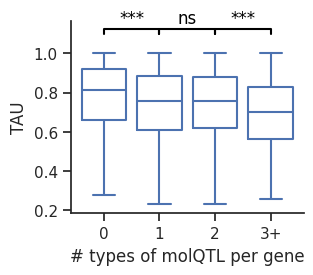

In [9]:
df_plot = df_tau
ylabel = 'TAU'

sns.set_theme(style="ticks")
plt.figure(figsize=(3, 2.5))

ax = sns.boxplot(data=df_plot, y=ylabel, x='num', fill=False, showfliers=False)
plt.xlabel('# types of molQTL per gene')
plt.xticks([0,1,2,3], [0,1,2,'3+'])

y_max = max(df_plot[ylabel]) * 1.1
#y_max=0.47
pairs=[(0,1), (1, 2), (2, 3)]
for pair in pairs:
    t_stat, p_value = stats.mannwhitneyu(df_plot.loc[df_plot['num']==pair[0],ylabel],
                                         df_plot.loc[df_plot['num']==pair[1],ylabel], alternative='two-sided')
    if p_value < 0.001:
        significance = '***'
    elif p_value < 0.01:
        significance = '**'
    elif p_value < 0.05:
        significance = '*'
    else:
        significance = 'ns' 
    ax.plot([pair[0], pair[0], pair[1], pair[1]], [y_max, y_max * 1.02, y_max * 1.02, y_max], lw=1.5, c='black')
    ax.text((pair[0] + pair[1]) * 0.5, y_max * 1.03, significance, ha='center', va='bottom', color='black')
plt.savefig('pdf/TAU_molQTL.pdf', dpi='figure', format='pdf', bbox_inches='tight')
sns.despine()

## phastcons

In [49]:
phastcons = pd.read_csv("/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/phastcons/chrAuto.phastcons.gene.cov0.5.txt", sep="\t", header=None, usecols=[3,4], names=['phenotype_id', 'PhastCons'])
df_phastcons = pd.merge(df_egene_count, phastcons, on="phenotype_id")
df_phastcons = df_phastcons.dropna(subset=['PhastCons'])
df_phastcons

,tissue,phenotype_id,nan_num,egene_num,num,Tissue,Sample size,PEER,PhastCons
0,Abomasum,BOK,2,2,2,Abomasum,228,30,0.095835
1,Abomasum,STK25,1,1,1,Abomasum,228,30,0.200962
2,Abomasum,LOC121817693,6,0,0,Abomasum,228,30,0.052438
3,Abomasum,LOC101101945,1,0,0,Abomasum,228,30,0.158393
4,Abomasum,SEPTIN2,1,1,1,Abomasum,228,30,0.097251
...,...,...,...,...,...,...,...,...,...
765105,Uterus,LOC121819689,6,0,0,Uterus,178,30,0.185672
765106,Uterus,GPHB5,6,1,1,Uterus,178,30,0.139436
765107,Uterus,PRLHR,6,0,0,Uterus,178,30,0.805499
765108,Uterus,LOC121818589,6,0,0,Uterus,178,30,0.104468


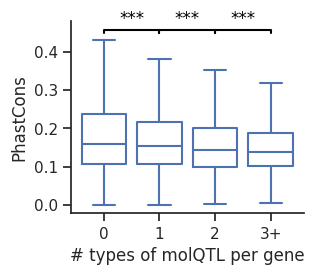

In [11]:
df_plot = df_phastcons
ylabel = 'PhastCons'

sns.set_theme(style="ticks")
plt.figure(figsize=(3, 2.5))

ax = sns.boxplot(data=df_plot, y=ylabel, x='num', fill=False, showfliers=False)
plt.xlabel('# types of molQTL per gene')
plt.xticks([0,1,2,3], [0,1,2,'3+'])

#y_max = max(df_plot[ylabel]) * 1.1
y_max=0.45
pairs=[(0,1), (1, 2), (2, 3)]
for pair in pairs:
    t_stat, p_value = stats.mannwhitneyu(df_plot.loc[df_plot['num']==pair[0],ylabel],
                                         df_plot.loc[df_plot['num']==pair[1],ylabel], alternative='two-sided')
    if p_value < 0.001:
        significance = '***'
    elif p_value < 0.01:
        significance = '**'
    elif p_value < 0.05:
        significance = '*'
    else:
        significance = 'ns' 
    ax.plot([pair[0], pair[0], pair[1], pair[1]], [y_max, y_max * 1.02, y_max * 1.02, y_max], lw=1.5, c='black')
    ax.text((pair[0] + pair[1]) * 0.5, y_max * 1.03, significance, ha='center', va='bottom', color='black')
plt.savefig('pdf/phastcons_molQTL.pdf', dpi='figure', format='pdf', bbox_inches='tight')
sns.despine()

## |kME|

In [24]:
kme = pd.read_csv('/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/01.MP1/02.stat/04.MP1/gene/featureCount/WGCNA/WGCNA_new/WGCNA/kME.txt', sep="\t")
df_kme = pd.merge(kme, df_egene_count, left_on=["Tissue", "GeneID"], right_on=["Tissue", "phenotype_id"])
df_kme

,GeneID,module,kME_value,|kME|,Tissue,tissue,phenotype_id,nan_num,egene_num,num,Sample size,PEER
0,A1BG,kME_ME0,0.179256,0.179256,Muscle,Muscle,A1BG,4,2,2,713,60
1,A4GALT,kME_ME0,0.101641,0.101641,Muscle,Muscle,A4GALT,4,1,1,713,60
2,AAAS,kME_ME0,-0.065793,0.065793,Muscle,Muscle,AAAS,2,1,1,713,60
3,AACS,kME_ME0,0.039329,0.039329,Muscle,Muscle,AACS,2,2,2,713,60
4,AADACL3,kME_ME0,0.028560,0.028560,Muscle,Muscle,AADACL3,4,2,2,713,60
...,...,...,...,...,...,...,...,...,...,...,...,...
968863,ZYG11A,kME_ME0,-0.008649,0.008649,Oviduct,Oviduct,ZYG11A,4,0,0,40,15
968864,ZYG11B,kME_ME1,0.431743,0.431743,Oviduct,Oviduct,ZYG11B,2,0,0,40,15
968865,ZYX,kME_ME9,0.820933,0.820933,Oviduct,Oviduct,ZYX,1,0,0,40,15
968866,ZZEF1,kME_ME12,0.417622,0.417622,Oviduct,Oviduct,ZZEF1,1,0,0,40,15


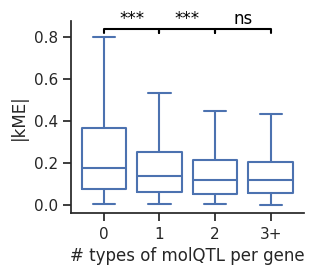

In [46]:
df_plot = df_kme
ylabel = '|kME|'

sns.set_theme(style="ticks")
plt.figure(figsize=(3, 2.5))

ax = sns.boxplot(data=df_plot, y=ylabel, x='num', fill=False, showfliers=False)
plt.xlabel('# types of molQTL per gene')
plt.xticks([0,1,2,3], [0,1,2,'3+'])

#y_max = max(df_plot[ylabel]) * 1.1
y_max=0.82
pairs=[(0,1), (1, 2), (2, 3)]
for pair in pairs:
    t_stat, p_value = stats.mannwhitneyu(df_plot.loc[df_plot['num']==pair[0],ylabel],
                                         df_plot.loc[df_plot['num']==pair[1],ylabel], alternative='two-sided')
    if p_value < 0.001:
        significance = '***'
    elif p_value < 0.01:
        significance = '**'
    elif p_value < 0.05:
        significance = '*'
    else:
        significance = 'ns' 
    ax.plot([pair[0], pair[0], pair[1], pair[1]], [y_max, y_max * 1.02, y_max * 1.02, y_max], lw=1.5, c='black')
    ax.text((pair[0] + pair[1]) * 0.5, y_max * 1.03, significance, ha='center', va='bottom', color='black')
plt.savefig('pdf/kme_molQTL.pdf', dpi='figure', format='pdf', bbox_inches='tight')
sns.despine()

# Fig. 2f

In [11]:
import pandas as pd
import argparse
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from scipy.interpolate import UnivariateSpline
from scipy.interpolate import PchipInterpolator
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
%matplotlib inline

In [5]:
path="/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL"
dt = pd.read_csv(f'{path}/TSS_TES/sheep_merged_molQTL.txt', sep='\t')
dt.set_index('bin', inplace=True)
dt

,x,eQTL,eeQTL,isoQTL,enQTL,sQTL,stQTL,3aQTL,background
bin,,,,,,,,,
1,1,0.001484,0.001178,0.001409,0.001601,0.001125,0.001271,0.000964,0.014223
2,2,0.001320,0.001229,0.001132,0.001138,0.000830,0.001013,0.001285,0.014638
3,3,0.001574,0.001188,0.001091,0.001222,0.000872,0.001056,0.001044,0.014627
4,4,0.001269,0.001027,0.001091,0.001053,0.000956,0.000894,0.001366,0.014667
5,5,0.001371,0.001138,0.000905,0.001770,0.000970,0.000948,0.001125,0.014581
...,...,...,...,...,...,...,...,...,...
66,66,0.001241,0.001168,0.000967,0.001348,0.000647,0.000819,0.000683,0.013211
67,67,0.001202,0.001007,0.001049,0.000969,0.000802,0.000819,0.001406,0.013020
68,68,0.001168,0.001077,0.000782,0.000843,0.000647,0.000969,0.000603,0.012429


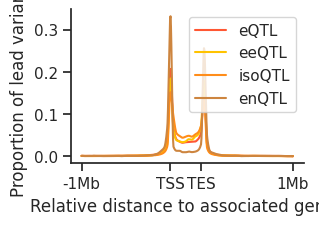

In [24]:
x_new = np.linspace(dt['x'].min(), dt['x'].max(), 500)
interpolated_data = {}

for qtl in dt.columns[1:5]:  # 跳过 'x' 列
    pchip = PchipInterpolator(dt['x'], dt[qtl])
    y_new = pchip(x_new)
    interpolated_data[qtl] = y_new

# 将插值后的数据存储在 DataFrame 中
interpolated_df = pd.DataFrame({'x': x_new})
for qtl, y_new in interpolated_data.items():
    interpolated_df[qtl] = y_new

# 绘制平滑曲线图
sns.set_theme(style="ticks")
plt.figure(figsize=(3, 2))
for qtl in dt.columns[1:5]:
    plt.plot(interpolated_df['x'], interpolated_df[qtl], label=qtl, color = color_dict[qtl])

plt.ylabel('Proportion of lead variants')
plt.xlabel('Relative distance to associated genes')
plt.xticks([1,30, 40,70], ['-1Mb','TSS', 'TES','1Mb'])
plt.legend()
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
#formatter = FuncFormatter(lambda y, _: f'{y * 100:.0f}')
#ax.yaxis.set_major_formatter(formatter)

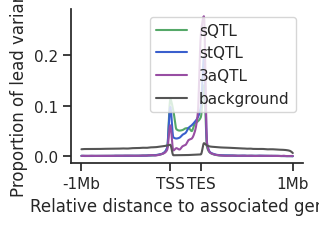

In [25]:
x_new = np.linspace(dt['x'].min(), dt['x'].max(), 500)
interpolated_data = {}

for qtl in dt.columns[5:]:  # 跳过 'x' 列
    pchip = PchipInterpolator(dt['x'], dt[qtl])
    y_new = pchip(x_new)
    interpolated_data[qtl] = y_new

# 将插值后的数据存储在 DataFrame 中
interpolated_df = pd.DataFrame({'x': x_new})
for qtl, y_new in interpolated_data.items():
    interpolated_df[qtl] = y_new

# 绘制平滑曲线图
sns.set_theme(style="ticks")
plt.figure(figsize=(3, 2))
for qtl in dt.columns[5:]:
    plt.plot(interpolated_df['x'], interpolated_df[qtl], label=qtl, color = color_dict[qtl])

plt.ylabel('Proportion of lead variants')
plt.xlabel('Relative distance to associated genes')
plt.xticks([1,30, 40,70], ['-1Mb','TSS', 'TES','1Mb'])
plt.legend()
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
#formatter = FuncFormatter(lambda y, _: f'{y * 100:.0f}')
#ax.yaxis.set_major_formatter(formatter)

# Fig. 2g

In [69]:
label_mapping = {'intergenic_region':'intergenic','upstream_gene':'upstream','downstream_gene':'downstream','5_prime_UTR':"5' UTR",'3_prime_UTR':"3' UTR",
                 '5_prime_UTR_premature_start_codon_gain':"5' UTR premature\nstart codon gain",'non_coding_transcript_exon':'non-coding\ntranscript exon',
                 'splice_region':'splice region','splice_acceptor':'splice acceptor','splice_donor':'splice donor','start_lost':'start lost','stop_lost':'stop lost',
                 'stop_gained':'stop gained','stop_retained':'stop retained','initiator_codon':'initiator codon',
                 "E1":"TssA", "E2":"TssAHet", "E3":"TxFlnk", "E4":"TxFlnkWk", "E5":"TxFlnkHet", "E6":"EnhA", "E7":"EnhAMe", "E8":"EnhAWk",
                 "E9":"EnhAHet", "E10":"EnhPois", "E11":"ATAC_Is", "E12":"TssBiv", "E13":"Repr", "E14":"ReprWk", "E15":"Qui"}

path="/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/functional_enrichment"
df1 = pd.DataFrame()
for tis in tislist:
    if os.path.isfile(f'{path}/{tis}/lead/FE_results.csv'):
        df_ = pd.read_csv(f'{path}/{tis}/lead/FE_results.csv')
        df_['Tissue'] = tis
        df1 = pd.concat([df1, df_])
df1['QTL'] = df1['QTL'].str.replace('.txt', '', regex=False)
df1['Annotation'] = df1['Annotation'].str.replace('.txt', '', regex=False)
df1['Annotation'] = df1['Annotation'].str.replace('_variant', '', regex=False)
df1['log2(fold enrichment)'] = np.log2(df1['Fold enrichment'])
df1 = df1.replace([np.inf, -np.inf], np.nan).reset_index(drop=True).dropna()
df1['Source'] = 'molQTL'

/storage/public/home/2020060185/.local/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [70]:
df2 = pd.DataFrame()
for tis in tislist:
    if os.path.isfile(f'{path}/{tis}/lead/FE_control_results.csv'):
        df_ = pd.read_csv(f'{path}/{tis}/lead/FE_control_results.csv')
        df_['Tissue'] = tis
        df2 = pd.concat([df2, df_])
df2['QTL'] = df2['QTL'].str.replace('.txt', '', regex=False)
df2['Annotation'] = df2['Annotation'].str.replace('.txt', '', regex=False)
df2['Annotation'] = df2['Annotation'].str.replace('_variant', '', regex=False)
df2['log2(fold enrichment)'] = np.log2(df2['Fold enrichment'])
df2 = df2.replace([np.inf, -np.inf], np.nan).reset_index(drop=True).dropna()
df2['Source'] = 'Control'

/storage/public/home/2020060185/.local/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [71]:
df = pd.concat([df1, df2], ignore_index=True)
df_ontology = df[~df['Annotation'].str.startswith('E')].reset_index(drop=True)
df_state = df[df['Annotation'].str.startswith('E')].reset_index(drop=True)
df['Annotation'] = df['Annotation'].replace(label_mapping)
df_ontology['Annotation'] = df_ontology['Annotation'].replace(label_mapping)
df_state['Annotation'] = df_state['Annotation'].replace(label_mapping)
df

,QTL,Annotation,Fold enrichment,95% CI Low,95% CI High,P-value,num_var,Tissue,log2(fold enrichment),Source
0,3aQTL,intergenic,1.067630,0.984434,1.157857,1.177561e-01,1575,Muscle,0.094411,molQTL
1,3aQTL,downstream,2.310164,2.151378,2.480670,7.685528e-77,1575,Muscle,1.207996,molQTL
2,3aQTL,5' UTR premature\nstart codon gain,0.630051,0.157678,2.517573,7.767833e-01,1575,Muscle,-0.666459,molQTL
3,3aQTL,EnhAHet,1.057675,0.979030,1.142637,1.663307e-01,1575,Muscle,0.080896,molQTL
4,3aQTL,upstream,1.292727,1.155897,1.445754,2.066962e-05,1575,Muscle,0.370417,molQTL
...,...,...,...,...,...,...,...,...,...,...
20845,enQTL,3' UTR,0.789716,0.618596,1.008171,6.039732e-02,2799,Oviduct,-0.340594,Control
20846,enQTL,intragenic,1.492923,0.929157,2.398754,1.004458e-01,2799,Oviduct,0.578140,Control
20847,enQTL,TxFlnkWk,0.904633,0.822685,0.994745,3.679202e-02,2799,Oviduct,-0.144595,Control
20848,enQTL,TxFlnk,0.879344,0.800734,0.965672,6.418971e-03,2799,Oviduct,-0.185500,Control


/tmp/ipykernel_620723/3233201663.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
/tmp/ipykernel_620723/3233201663.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")


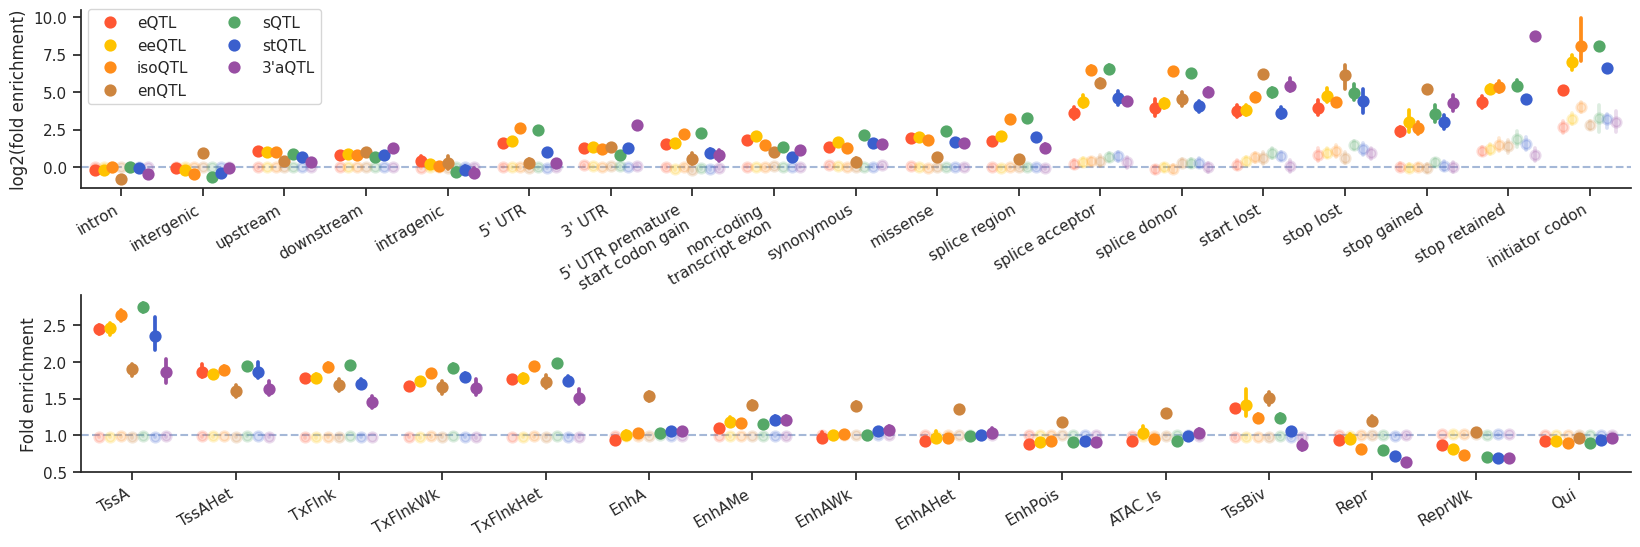

In [73]:
sns.set_theme(style="ticks")
fig, axes = plt.subplots(nrows=2, ncols=1, sharex=False, sharey=False, figsize=(20, 6))

x_order1=['intron', 'intergenic', 'upstream', 'downstream', 'intragenic', "5' UTR","3' UTR", "5' UTR premature\nstart codon gain", 'non-coding\ntranscript exon',
          'synonymous', 'missense', 'splice region', 'splice acceptor', 'splice donor', 'start lost', 'stop lost', 'stop gained', 'stop retained', 'initiator codon']
x_order2=["TssA", "TssAHet", "TxFlnk", "TxFlnkWk", "TxFlnkHet", "EnhA", "EnhAMe", "EnhAWk", "EnhAHet", "EnhPois", "ATAC_Is", "TssBiv", "Repr", "ReprWk", "Qui"]

# ontology
plt.subplot(2, 1, 1)
plt.axhline(y=0, color='b', alpha=.5, linestyle='--')

# control
ax = sns.pointplot(data=df_ontology[df_ontology['Source']=='Control'], x="Annotation", y="log2(fold enrichment)", palette=color_dict, legend=False,
                   hue_order=['eQTL', 'eeQTL', 'isoQTL', 'enQTL', 'sQTL', 'stQTL', '3aQTL'],
                   hue="QTL", markers="o", dodge=.65, alpha=.2, linestyle='none', order=x_order1)

# molQTL
ax = sns.pointplot(data=df_ontology[df_ontology['Source']=='molQTL'], x="Annotation", y="log2(fold enrichment)", palette=color_dict,
                   hue_order=['eQTL', 'eeQTL', 'isoQTL', 'enQTL', 'sQTL', 'stQTL', '3aQTL'],
                   hue="QTL", markers="o", dodge=.65, linestyle='none', order=x_order1)

ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
plt.gca().get_legend().get_texts()[-1].set_text("3'aQTL")
sns.move_legend(ax,"upper left", ncol=2, title=None, bbox_to_anchor=(0, 1.05))
plt.xlabel('')

# state
plt.subplot(2, 1, 2)
plt.axhline(y=1, color='b', alpha=.5, linestyle='--')

# control
ax = sns.pointplot(data=df_state[df_state['Source']=='Control'], x="Annotation", y="Fold enrichment", palette=color_dict, legend=False,
                   hue_order=['eQTL', 'eeQTL', 'isoQTL', 'enQTL', 'sQTL', 'stQTL', '3aQTL'],
                   hue="QTL", markers="o", dodge=.65, alpha=.2, linestyle='none', order=x_order2)

# molQTL
ax = sns.pointplot(data=df_state[df_state['Source']=='molQTL'], x="Annotation", y="Fold enrichment", palette=color_dict, legend=False,
                   hue_order=['eQTL', 'eeQTL', 'isoQTL', 'enQTL', 'sQTL', 'stQTL', '3aQTL'],
                   hue="QTL", markers="o", dodge=.65, linestyle='none', order=x_order2)

ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
plt.xlabel('')
sns.despine()
fig.subplots_adjust(hspace=0.6)
plt.savefig('pdf/molQTL_enrichment_numbers.pdf', dpi='figure', format='pdf', bbox_inches='tight')